In [3]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

In [8]:
def getExactState(n_qubits):
    # Create an initial state (|00...0>)
    initial_state = np.zeros(2**n_qubits)
    #print('Initial array:', initial_state)
    initial_state[0] = 1
    pure_state = DensityMatrix(initial_state)

    return pure_state
def getInputRho(epsilon, k):

    # Create a Quantum Circuit acting on a quantum register of d qubits

    depolarizing = depolarizing_error(epsilon, k)
    qc = QuantumCircuit(k)
    qc.append(depolarizing, [0, k-1])
    state = DensityMatrix(qc)

def circuit_with_noise_at_end(qc, k, Lambda,start=1):
    # Define the depolarizing error
    depolarizing = depolarizing_error(Lambda, k)

    # Apply the depolarizing noise to each d-sized register
    qc.append(depolarizing, range(start, start+k))  # Second register
    qc.append(depolarizing, range(start+k, start+2*k))  # Third register
    qc.append(depolarizing, range(start+2*k, start+3*k))  # Fourth register

    return qc
def getRhoPrimeWithSWAPNET(Lambda,N_trials,k):

    qc = QuantumCircuit(3*k + 1)
    qc = circuit_with_noise_at_end(qc, k, Lambda)

    for _ in range(N_trials): 
        qc.reset(0)
        qc.h(0)      # Apply Hadamard
        for i in range(k):
            qc.cswap(0, i+1, i+k+1)  # Control qubit 0, target q1 and q2
        qc.h(0)
        qc.x(0)
        for i in range(k):
            qc.cswap(0, i+k+1, i+2*k+1)  # Control qubit 0, target q2 and q3
        qc.x(0)

    state = DensityMatrix(qc)
    rhoprime = partial_trace(state,[i for i in range(1+2*k)] )

    return rhoprime

# Benchmarking the Noiseless Case

1. Benchmark the fidelity against theoretical limit
2. Compare w and w/o post-selection
3. Benchmark SWAPNET with GHZ as ancillae

In [27]:
#Simultation code
list_of_Lambda=[i * 0.01 for i in range(101)]
fids={}
list_of_purified_fidelity_theory=[]


k=2
pure_state=getExactState(k)
for Lambda in list_of_Lambda:
    print('Looking at Lambda of', Lambda)
    fids[0]= fids.get(0,[])+[state_fidelity(getRhoPrimeWithSWAPNET(Lambda,0,k), pure_state)]
    fids[1]= fids.get(1,[])+[state_fidelity(getRhoPrimeWithSWAPNET(Lambda,1,k), pure_state)]
    fids[2]= fids.get(2,[])+[state_fidelity(getRhoPrimeWithSWAPNET(Lambda,2,k), pure_state)]
    fids[3]= fids.get(3,[])+[state_fidelity(getRhoPrimeWithSWAPNET(Lambda,3,k), pure_state)]
    fids[4]= fids.get(4,[])+[state_fidelity(getRhoPrimeWithSWAPNET(Lambda,4,k), pure_state)]
    fids[5]= fids.get(5,[])+[state_fidelity(getRhoPrimeWithSWAPNET(Lambda,5,k), pure_state)]
    list_of_purified_fidelity_theory.append(1/8*(-2+Lambda)*(1+Lambda)*(-4+3*Lambda))



Looking at Lambda of 0.0
Looking at Lambda of 0.01
Looking at Lambda of 0.02
Looking at Lambda of 0.03
Looking at Lambda of 0.04
Looking at Lambda of 0.05
Looking at Lambda of 0.06
Looking at Lambda of 0.07
Looking at Lambda of 0.08
Looking at Lambda of 0.09
Looking at Lambda of 0.1
Looking at Lambda of 0.11
Looking at Lambda of 0.12
Looking at Lambda of 0.13
Looking at Lambda of 0.14
Looking at Lambda of 0.15
Looking at Lambda of 0.16
Looking at Lambda of 0.17
Looking at Lambda of 0.18
Looking at Lambda of 0.19
Looking at Lambda of 0.2
Looking at Lambda of 0.21
Looking at Lambda of 0.22
Looking at Lambda of 0.23
Looking at Lambda of 0.24
Looking at Lambda of 0.25
Looking at Lambda of 0.26
Looking at Lambda of 0.27
Looking at Lambda of 0.28
Looking at Lambda of 0.29
Looking at Lambda of 0.3
Looking at Lambda of 0.31
Looking at Lambda of 0.32
Looking at Lambda of 0.33
Looking at Lambda of 0.34
Looking at Lambda of 0.35000000000000003
Looking at Lambda of 0.36
Looking at Lambda of 0.37
L

In [28]:
print('Lambda Values:',list_of_Lambda)
print('NQPA=0:',fids[0])
print('NQPA=1:',fids[1])
print('NQPA=2:',fids[2])
print('NQPA=3:',fids[3])
print('NQPA=4:',fids[4])
print('NQPA=5:',fids[5])
print('Theory Max:',list_of_purified_fidelity_theory)



Lambda Values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8200000000000001, 0.8300000000000001, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.9400000000000001, 0.9500000000000001, 0.96, 0.97, 0.98, 0.99, 1.0]
NQPA=0: [0.9999999999999987, 0.9924999999999994, 0.9850000000000017, 0.9774999999999986, 0.9700000000000022, 0.962499999999997, 0.9549999999999992, 0.9474999999999999, 0.94, 0.9325000000000013, 0.9250000000000009, 0.9175000000000013, 0.910000000

In [34]:
import pandas as pd
from pathlib import Path

# Assuming:
# - list_of_Lambda is a list of lambda values
# - fids is a list of lists, where fids[i] is the fidelity list for NQPA = i
# - you want to save for NQPA = 0, 1, 2, 3

base_path = Path("../shared_data/unitary_evolved_full_dm/simulation_outputs/unitary_evolved_full_dm_k2_lambda_0_1_100")

for nqpa_level in range(4):  # NQPA = 0 to 3
    output_folder = base_path / f"nqpa{nqpa_level}"
    output_folder.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame({
        "lambda": list_of_Lambda,
        f"QPA_{nqpa_level}": fids[nqpa_level]
    })

    df.to_csv(output_folder / "combined_lambdas.csv", index=False)
    print(f"[+] Saved combined_lambdas.csv for NQPA={nqpa_level}")


[+] Saved combined_lambdas.csv for NQPA=0
[+] Saved combined_lambdas.csv for NQPA=1
[+] Saved combined_lambdas.csv for NQPA=2
[+] Saved combined_lambdas.csv for NQPA=3


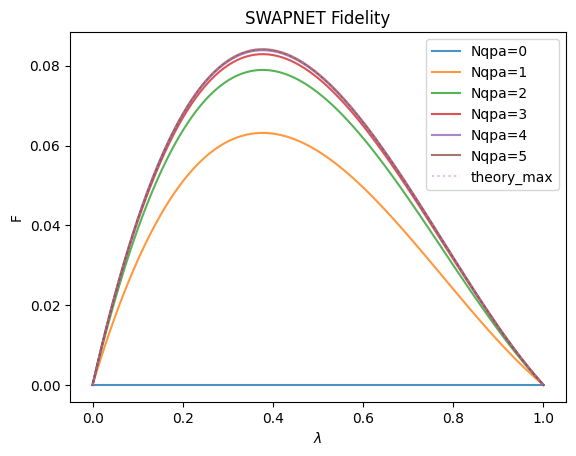

In [30]:
plt.plot(list_of_Lambda, np.array(fids[0])-np.array(fids[0]),label=f'Nqpa={0}', alpha=0.8)
plt.plot(list_of_Lambda, np.array(fids[1])-np.array(fids[0]),label=f'Nqpa={1}', alpha=0.8)
plt.plot(list_of_Lambda, np.array(fids[2])-np.array(fids[0]),label=f'Nqpa={2}', alpha=0.8)
plt.plot(list_of_Lambda, np.array(fids[3])-np.array(fids[0]),label=f'Nqpa={3}', alpha=0.8)
plt.plot(list_of_Lambda, np.array(fids[4])-np.array(fids[0]),label=f'Nqpa={4}', alpha=0.8)
plt.plot(list_of_Lambda, np.array(fids[5])-np.array(fids[0]),label=f'Nqpa={5}', alpha=0.8)

plt.plot(list_of_Lambda,np.array(list_of_purified_fidelity_theory)-np.array(fids[0]),label='theory_max', alpha=0.5, linestyle='dotted')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1_n1,label='SWAPNET12-13 flag=1 n='+str(1), alpha=0.8, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1,label='SWAPNET12-13 flag=1 n='+str(10), alpha=0.8)


    
plt.title("SWAPNET Fidelity")
plt.xlabel("$\lambda$")
plt.ylabel("F")
plt.legend()

In [ ]:
#Simultation code with postselection
list_of_Lambda=[i * 0.1 for i in range(11)]

list_of_purified_fidelity_swap=[]
for Lambda in list_of_Lambda:
    list_of_purified_fidelity_swap.append(state_fidelity(getRhoPrimeWithSWAPTest(Lambda), pure_state))

rows, cols = 2, 0
value = 0
list_of_purified_fidelity= [[value] * cols for _ in range(rows)]
list_of_unpurified_fidelity=[]
list_of_purified_fidelity_theory=[]
for Lambda in list_of_Lambda:
    for N_Trot in range(rows):
        list_of_purified_fidelity[N_Trot].append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,10**N_Trot,1), pure_state))
    list_of_unpurified_fidelity.append(state_fidelity(getInputRho(Lambda,1,1,1,10), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+Lambda)*(1+Lambda)*(-4+3*Lambda))


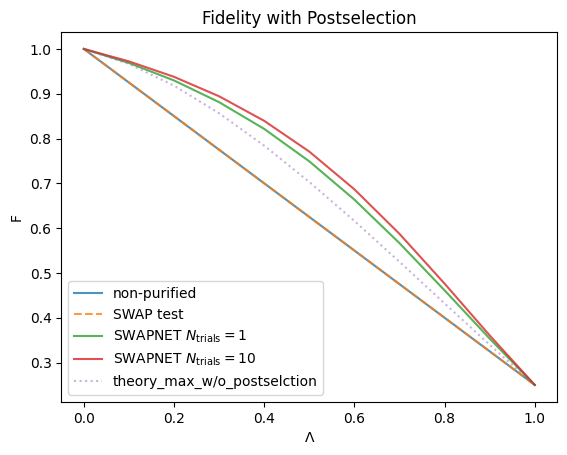

In [42]:
plt.plot(list_of_Lambda,list_of_unpurified_fidelity,label='non-purified', alpha=0.8)
plt.plot(list_of_Lambda,list_of_purified_fidelity_swap,label='SWAP test', alpha=0.8, linestyle='dashed')
for Lambda in range(rows):
    plt.plot(list_of_Lambda,list_of_purified_fidelity[Lambda],label=r'SWAPNET $N_{\mathrm{trials}} = {}$'+str(10**Lambda), alpha=0.8)
plt.plot(list_of_Lambda,list_of_purified_fidelity_theory,label='theory_max_w/o_postselction', alpha=0.5, linestyle='dotted')
plt.title("Fidelity with Postselection")
plt.xlabel("$\Lambda$")
plt.ylabel("F")
plt.legend()

## SWAPNET with GHZ ancilla resource

We see agreement with the original circuit without GHZ

In [44]:
def getRhoPrimeWithSWAPNETGHZ(Lambda,n,post_selection):

    J=1
    h=1 
    t=1
    N_Trot=10

    list_rho_odd=[]
    list_rho_even=[]
    list_p00or11_odd=[]
    list_p00or11_even=[]
    list_p01or10_odd=[]
    list_p01or10_even=[]

    qc_odd = QuantumCircuit(8)
    qc_odd.reset(0)
    qc_odd.reset(1)
    
    # Apply the Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.cx(0,1)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 2, 4)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(1, 3, 5)
    
    # Apply the second Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.h(1)

    
    qc_even = QuantumCircuit(8)
    qc_even.reset(0)
    qc_even.reset(1)
    # Apply the Hadamard gate to the first and second qubits
    qc_even.h(0)
    qc_even.cx(0,1)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 2, 6)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(1, 3, 7)
    
    # Apply the second Hadamard gate to the first and second qubit
    qc_even.h(0)
    qc_even.h(1)


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(8)
    
    qc=tfimCircuitWithNoiseAtEnd(qc, 2, 3, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 4, 5, J, h, t, N_Trot, Lambda)
    qc=tfimCircuitWithNoiseAtEnd(qc, 6, 7, J, h, t, N_Trot, Lambda)
    
    # Apply the Hadamard gate to the first and second qubits
    qc.h(0)
    qc.cx(0,1)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 2, 4)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(1, 3, 5)
    
    # Apply the second Hadamard gate to the first and second qubits
    qc.h(0)
    qc.h(1)
    
    state = DensityMatrix(qc)

    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 8-qubit projection operator using tensor products
    projection_operator00 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P0))
    projection_operator01 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P0))
    projection_operator10 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P1))
    projection_operator11 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P1))
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11

    list_p00or11_odd.append(prob_00+prob_11)
    list_p01or10_odd.append(prob_10+prob_01)
    
    # Trace out qubits q0, q1, q2, q3, q4 and q5
    list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    state=state.evolve(qc_even)
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11


    list_p00or11_even.append(prob_00+prob_11)
    list_p01or10_even.append(prob_10+prob_01)
    
    
    # Trace out qubits q0, q1, q2, q3, q6, and q7
    list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
    
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    for i in range(n-1):
            # Block A
            
            state=state.evolve(qc_odd)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
    
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
            list_p00or11_odd.append(prob_00+prob_11)
            list_p01or10_odd.append(prob_10+prob_01)
            
            # Trace out qubits q0, q1, q2, q3, q4 and q5
            list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
            
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

            # Block B
            state=state.evolve(qc_even)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
            
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
        
        
            list_p00or11_even.append(prob_00+prob_11)
            list_p01or10_even.append(prob_10+prob_01)
            
            
            # Trace out qubits q0, q1, q2, q3, q6, and q7
            list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
        
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
        

    
    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    purified_rho=list_p01or10_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p00or11_odd[0]*list_p01or10_even[0]*list_rho_even[0]
    
    for j in range(n-1):
        #print(j)
        product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:j+1])
        product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:j+1])
        product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

        purified_rho=purified_rho+product_list_p00or11*list_p01or10_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p00or11*list_p00or11_odd[j+1]*list_p01or10_even[j+1]*list_rho_even[j+1]

    product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:n])
    product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:n])
    product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

    if post_selection > 0:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        purified_rho=purified_rho+product_list_p00or11*partial_trace(state, [0, 1, 2, 3, 4, 5])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho)

In [49]:
list_of_purified_fidelity_flag0_10=[]
list_of_purified_fidelity_flag1=[]
list_of_purified_fidelity_n1=[]
list_of_purified_fidelity_n1_GHZ=[]
list_of_purified_fidelity_flag1_n1=[]
list_of_purified_fidelity_flag0_n5=[]
list_of_purified_fidelity_flag1_n5=[]

list_of_purified_fidelity_theory=[]

for Lambda in list_of_Lambda:
    list_of_purified_fidelity_n1.append(state_fidelity(getRhoPrimeWithSWAPNET(Lambda,1), pure_state))
    list_of_purified_fidelity_n1_GHZ.append(state_fidelity(getRhoPrimeWithSWAPNETGHZ(Lambda,1,0), pure_state))
    # list_of_purified_fidelity_flag1_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,1,1), pure_state))
    # list_of_purified_fidelity_flag0_n5.append(state_fidelity(getRhoPrimeWithSWAPNETGHZ(Lambda,5,0), pure_state))
    # list_of_purified_fidelity_flag1_n5.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,5,1), pure_state))
    # list_of_purified_fidelity_flag0_10.append(state_fidelity(getRhoPrimeWithSWAPNETGHZ(Lambda,10,0), pure_state))
    # list_of_purified_fidelity_flag1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,10,1), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+Lambda)*(1+Lambda)*(-4+3*Lambda))


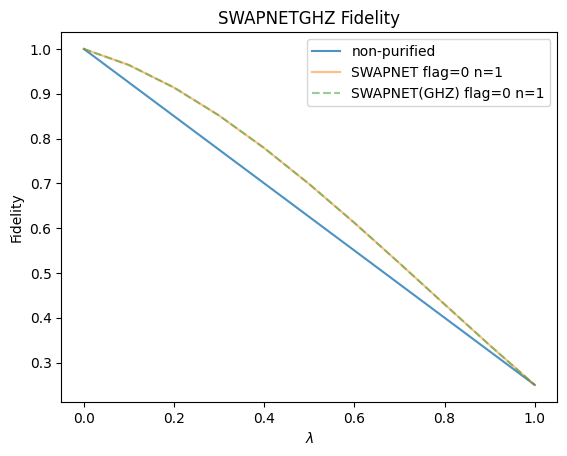

In [ ]:
plt.plot(list_of_epsilon,list_of_unpurified_fidelity,label='non-purified', alpha=0.8)
# plt.plot(list_of_epsilon,list_of_purified_fidelity_swap,label='swap-test12', alpha=0.8, linestyle='dashed')

plt.plot(list_of_epsilon,list_of_purified_fidelity_n1,label='SWAPNET flag=0 n='+str(1), alpha=0.5)
plt.plot(list_of_epsilon,list_of_purified_fidelity_n1_GHZ,label='SWAPNET(GHZ) flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n5,label='SWAPNET12-13 flag=0 n='+str(5), alpha=0.5)
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0,label='SWAPNET12-13 flag=0 n='+str(10), alpha=0.5, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1_n1,label='SWAPNET12-13 flag=1 n='+str(1), alpha=0.8, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag1,label='SWAPNET12-13 flag=1 n='+str(10), alpha=0.8)


    
plt.title("SWAPNETGHZ Fidelity")
plt.xlabel("$\epsilon$")
plt.ylabel("Fidelity")
plt.legend()

# Benchmarking the Noisy Case

We add gate-level noise to the circuit (without GHZ) and benchmark the fidelity

In [8]:
def getRhoPrimeWithNoisySWAPTest(t, J, h, N_Trot, epsilon):

    depolarizing = depolarizing_error(epsilon, 1)
    #two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    three_qubit_depolarizing = depolarizing_error(epsilon, 3)
    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(5)

    qc=tfimCircuitWithGateNoise(qc, 1, 2, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 3, 4, J, h, t, N_Trot, epsilon)
        
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    qc.append(three_qubit_depolarizing, [0,1,3])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    qc.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    state = DensityMatrix(qc)

    # Trace out all qubits except q0 to get the reduced density matrix for q0
    # output_rho _q0 = partial_trace(state, [1, 2, 3, 4])
    
    # # Extract probabilities from the reduced density matrix of q0
    # prob_0 = output_rho _q0.data[0, 0].real  # Probability of q0 being in |0>
    # prob_1 = output_rho _q0.data[1, 1].real  # Probability of q0 being in |1>

    # Create the 5-qubit projection operator using tensor products

      # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))


    #outcome0
    rho_outcome_0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    normalized_rho_outcome_0=rho_outcome_0/prob_0

    #outcome1
    rho_outcome_1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    normalized_rho_outcome_1=rho_outcome_1/prob_1

    # Trace out qubits q0, q3, and q4
    output_rho0 = partial_trace(DensityMatrix(normalized_rho_outcome_0), [0, 1, 2])
    output_rho1 = partial_trace(DensityMatrix(normalized_rho_outcome_1), [0, 1, 2])

    purified_rho=prob_0*output_rho0  + prob_1*output_rho1 #for both outcomes, trace out one reg, therefore the overall state should be as if the purification is not done

    return purified_rho

In [9]:
def getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot, N_trials, post_selection, epsilon):

    list_rho_odd=[]
    list_rho_even=[]
    list_p0_odd=[]
    list_p0_even=[]
    list_p1_odd=[]
    list_p1_even=[]

    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    three_qubit_depolarizing = depolarizing_error(epsilon, 3)

    qc_odd = QuantumCircuit(7)
    qc_odd.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_odd.h(0)
    qc_odd.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 1, 3)
    qc_odd.append(three_qubit_depolarizing, [0,1,3])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(0, 2, 4)
    qc_odd.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second Hadamard gate to the first qubit
    qc_odd.h(0)
    qc_odd.append(depolarizing, [0])

    
    qc_even = QuantumCircuit(7)
    qc_even.reset(0)
    # Apply the Hadamard gate to the first qubit
    qc_even.h(0)
    qc_even.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 1, 5)
    qc_even.append(three_qubit_depolarizing, [0,1,5])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(0, 2, 6)
    qc_even.append(three_qubit_depolarizing, [0,2,6])
    
    # Apply the second Hadamard gate to the first qubit
    qc_even.h(0)
    qc_even.append(depolarizing, [0])


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(7)

    qc=tfimCircuitWithGateNoise(qc, 1, 2, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 3, 4, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 5, 6, J, h, t, N_Trot, epsilon)    
    
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    qc.append(three_qubit_depolarizing, [0,1,3])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    qc.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    qc.append(depolarizing, [0])
    
    state = DensityMatrix(qc)


    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 7-qubit projection operator using tensor products
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_odd.append(prob_0)
    
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_odd.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q3, and q4
    list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 3, 4]))

    # update the state
    state=DensityMatrix(post_meas_rho0)
    # print(state)

    state=state.evolve(qc_even)
    # print(state)
    
    projected_rho0=projection_operator0@state@projection_operator0.adjoint()
    # print(projected_rho0)
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    post_meas_rho0=projected_rho0/prob_0
    # print(post_meas_rho0)
    list_p0_even.append(prob_0)
            
    projected_rho1=projection_operator1@state@projection_operator1.adjoint()
    # print(projected_rho1)
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    post_meas_rho1=projected_rho1/prob_1
    # print(post_meas_rho1)
    list_p1_even.append(prob_1)
    
    # Trace out qubits q0, q1, q2, q5, and q6
    list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 5, 6]))

    # update the state
    state=DensityMatrix(post_meas_rho0)

    
    for i in range(N_trials-1):
            # Block A
            
            state=state.evolve(qc_odd)
            
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_odd.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_odd.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q3, and q4
            list_rho_odd.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 3, 4]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


            # Block B
            state=state.evolve(qc_even)
    
            projected_rho0=projection_operator0@state@projection_operator0.adjoint()
            prob_0=np.trace(projection_operator0@state@projection_operator0)
            post_meas_rho0=projected_rho0/prob_0
            list_p0_even.append(prob_0)
            
            projected_rho1=projection_operator1@state@projection_operator1.adjoint()
            prob_1=np.trace(projection_operator1@state@projection_operator1)
            post_meas_rho1=projected_rho1/prob_1
            list_p1_even.append(prob_1)
            
            # Trace out qubits q0, q1, q2, q5, and q6
            list_rho_even.append(partial_trace(DensityMatrix(post_meas_rho1), [0, 1, 2, 5, 6]))
        
            # update the state
            state=DensityMatrix(post_meas_rho0)


    

    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    
    purified_rho=list_p1_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p0_odd[0]*list_p1_even[0]*list_rho_even[0]
    
    for j in range(N_trials-1):
        #print(j)
        product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:j+1])
        product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:j+1])
        product_list_p0=product_list_p0_odd*product_list_p0_even

        purified_rho=purified_rho+product_list_p0*list_p1_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p0*list_p0_odd[j+1]*list_p1_even[j+1]*list_rho_even[j+1]

    product_list_p0_odd=reduce(lambda x, y: x * y, list_p0_odd[:N_trials])
    product_list_p0_even=reduce(lambda x, y: x * y, list_p0_even[:N_trials])
    product_list_p0=product_list_p0_odd*product_list_p0_even

    if post_selection > 0:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 3, 4, 5, 6])
    else:
        purified_rho=purified_rho+product_list_p0*partial_trace(state, [0, 1, 2, 3, 4])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho)


Getting some intuition for a fixed $N_\mathrm{Trot}$

In [11]:
list_of_epsilon=[i * 0.01 for i in range(11)]

list_of_unpurified_fidelity=[]
list_of_purified_fidelity_swap_noisy=[]
list_of_purified_fidelity_n1_noisy=[]
list_of_purified_fidelity_n2_noisy=[]
list_of_purified_fidelity_theory=[]

t=1
N_Trot=5
J=1
h=1
pure_state = getExactState(J, h, t)

for epsilon in list_of_epsilon:
    list_of_purified_fidelity_swap_noisy.append(state_fidelity(getRhoPrimeWithNoisySWAPTest(t, J, h, N_Trot, epsilon), pure_state))
    list_of_purified_fidelity_n1_noisy.append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot, 1, 0, epsilon), pure_state))
    list_of_purified_fidelity_n2_noisy.append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot, 3, 0, epsilon), pure_state))
    list_of_unpurified_fidelity.append(state_fidelity(getInputRho(epsilon, J, h, t, N_Trot,1), pure_state))

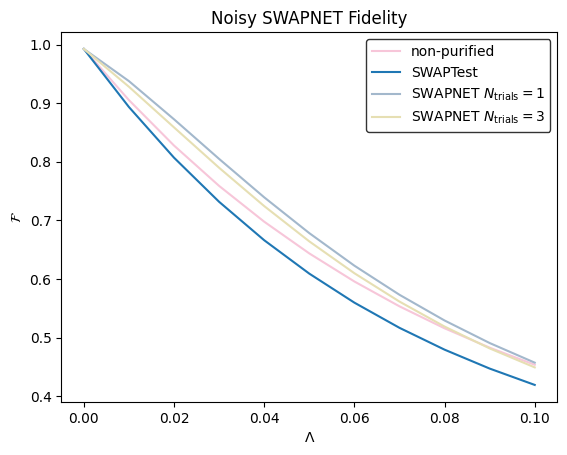

In [12]:
plt.rcParams['text.usetex']=False
# plt.rcParams['font.serif']='Computer Modern'
# plt.rcParams['text.latex.preamble']=r'\usepackage{amsmath}'
plt.plot(list_of_epsilon,list_of_unpurified_fidelity,label='non-purified', color='#F7C6D9')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,list_of_purified_fidelity_swap_noisy,label='SWAPTest')
plt.plot(list_of_epsilon,list_of_purified_fidelity_n1_noisy,label='SWAPNET $N_\mathrm{trials}=1$', color = '#A3B8CC')
plt.plot(list_of_epsilon,list_of_purified_fidelity_n2_noisy,label='SWAPNET $N_\mathrm{trials}=3$', color = '#E6DFB3')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')
    
plt.title("Noisy SWAPNET Fidelity")

plt.xlabel("$\\Lambda$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')



## Optimizing for $N_{\mathrm{Trot}}$

In [75]:
list_of_epsilon=[i * 0.01 for i in range(11)]
t=1
J=1
h=1
N_Trot_max=5
# list_of_purified_fidelity_flag0_n1=[]
list_of_purified_fidelity_n1_noisy=[[] for _ in range(N_Trot_max)]
list_of_purified_fidelity_n2_noisy=[[] for _ in range(N_Trot_max)]
# list_of_purified_fidelity_flag0_n2_noisy=[]
list_of_unpurified_fidelity=[[] for _ in range(N_Trot_max)]
# list_of_purified_fidelity_theory=[]

pure_state = getExactState(J, h, t)


for N_Trot in range(N_Trot_max):
    for epsilon in list_of_epsilon:
        # list_of_purified_fidelity_flag0_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,t,N,1,1), pure_state))
        list_of_purified_fidelity_n1_noisy[N_Trot].append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot+1, 1,0,epsilon), pure_state))
        list_of_purified_fidelity_n2_noisy[N_Trot].append(state_fidelity(getRhoPrimeWithNoisySWAPNET(t, J, h, N_Trot+1, 2,0,epsilon), pure_state))
        list_of_unpurified_fidelity[N_Trot].append(state_fidelity(getInputRho(epsilon, J, h, t, N_Trot+1,1), pure_state))

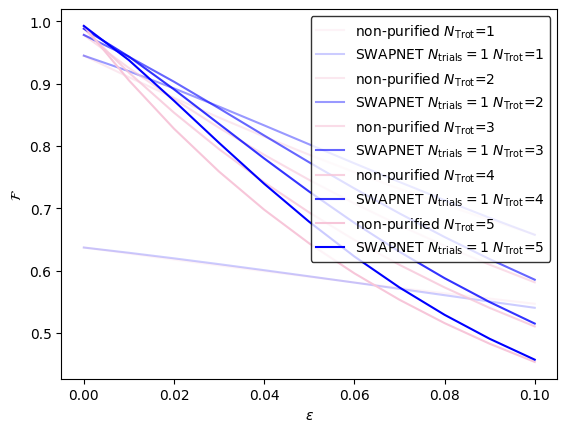

In [76]:
plt.rcParams['text.usetex']=False

for N_Trot in range(N_Trot_max):
    plt.plot(list_of_epsilon,list_of_unpurified_fidelity[N_Trot],label='non-purified'+' $N_\mathrm{Trot}$='+str(N_Trot+1), color='#F7C6D9',alpha=(N_Trot+1)/N_Trot_max)
    plt.plot(list_of_epsilon,list_of_purified_fidelity_n1_noisy[N_Trot],label='SWAPNET $N_\mathrm{trials}=1$'+' $N_\mathrm{Trot}$='+str(N_Trot+1), color = 'b',alpha=(N_Trot+1)/N_Trot_max)
    
plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')

Maixmize over all $N_\mathrm{Trot}$

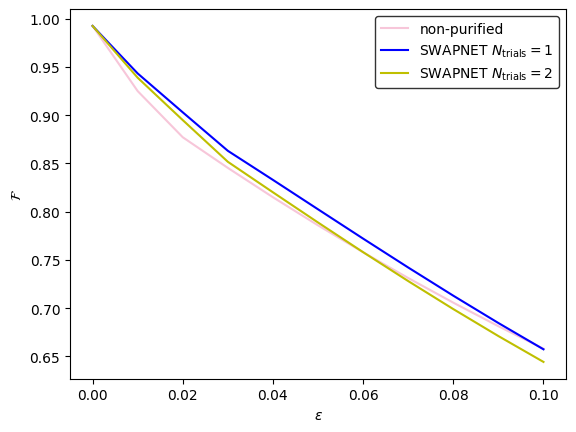

In [78]:
plt.rcParams['text.usetex']=False

max_list_of_fidelity=np.max(np.array(list_of_unpurified_fidelity), axis=0)
max_list_of_purified_fidelity_flag0_n1_noisy=np.max(np.array(list_of_purified_fidelity_n1_noisy), axis=0)
max_list_of_purified_fidelity_flag0_n2_noisy=np.max(np.array(list_of_purified_fidelity_n2_noisy), axis=0)

plt.plot(list_of_epsilon,max_list_of_fidelity,label='non-purified', color='#F7C6D9')
plt.plot(list_of_epsilon,max_list_of_purified_fidelity_flag0_n1_noisy,label='SWAPNET $N_\mathrm{trials}=1$', color = 'b')
plt.plot(list_of_epsilon,max_list_of_purified_fidelity_flag0_n2_noisy,label='SWAPNET $N_\mathrm{trials}=2$', color = 'y')
    
plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')

## Noisy SWAPNET-GHZ

In [ ]:
def getRhoPrimeWithNoisySWAPNETGHZ(t, J, h, N_Trot, N_trials, post_select,epsilon):

    list_rho_odd=[]
    list_rho_even=[]
    list_p00or11_odd=[]
    list_p00or11_even=[]
    list_p01or10_odd=[]
    list_p01or10_even=[]

    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    three_qubit_depolarizing = depolarizing_error(epsilon, 3)

    qc_odd = QuantumCircuit(8)
    qc_odd.reset(0)
    qc_odd.reset(1)
    
    # Apply the Hadamard gate to the first and second qubits
    qc_odd.h(0)
    # qc_odd.append(depolarizing, [0])
    qc_odd.cx(0,1)
    qc_odd.append(two_qubit_depolarizing, [0,1])

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 2, 4)
    qc_odd.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(1, 3, 5)
    qc_odd.append(three_qubit_depolarizing, [1,3,5])
    
    # Apply the second Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.append(depolarizing, [0])
    
    qc_odd.h(1)
    qc_odd.append(depolarizing, [1])

    
    qc_even = QuantumCircuit(8)
    qc_even.reset(0)
    qc_even.reset(1)
    
    # Apply the Hadamard gate to the first and second qubits
    qc_even.h(0)
    # qc_even.append(depolarizing, [0])
    qc_even.cx(0,1)
    qc_even.append(two_qubit_depolarizing, [0,1])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 2, 6)
    qc_even.append(three_qubit_depolarizing, [0,2,6])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(1, 3, 7)
    qc_even.append(three_qubit_depolarizing, [1,3,7])
    
    # Apply the second Hadamard gate to the first and second qubit
    qc_even.h(0)
    qc_even.append(depolarizing, [0])
    
    qc_even.h(1)
    qc_even.append(depolarizing, [1])


    
    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(8)

    qc=tfimCircuitWithGateNoise(qc, 2, 3, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 4, 5, J, h, t, N_Trot, epsilon)
    qc=tfimCircuitWithGateNoise(qc, 6, 7, J, h, t, N_Trot, epsilon)

    # Apply the Hadamard gate to the first and second qubits
    qc.h(0)
    # qc.append(depolarizing, [0])
    qc.cx(0,1)
    qc.append(two_qubit_depolarizing, [0,1])
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 2, 4)
    qc.append(three_qubit_depolarizing, [0,2,4])
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(1, 3, 5)
    qc.append(three_qubit_depolarizing, [1,3,5])
    
    # Apply the second Hadamard gate to the first and second qubits
    qc.h(0)
    qc.append(depolarizing, [0])
    
    qc.h(1)
    qc.append(depolarizing, [1])
    
    state = DensityMatrix(qc)

    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    
    # Create the 8-qubit projection operator using tensor products
    projection_operator00 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P0))
    projection_operator01 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P0))
    projection_operator10 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P1))
    projection_operator11 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P1))
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11

    list_p00or11_odd.append(prob_00+prob_11)
    list_p01or10_odd.append(prob_10+prob_01)
    
    # Trace out qubits q0, q1, q2, q3, q4 and q5
    list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    state=state.evolve(qc_even)
    
    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00
    
    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11


    list_p00or11_even.append(prob_00+prob_11)
    list_p01or10_even.append(prob_10+prob_01)
    
    
    # Trace out qubits q0, q1, q2, q3, q6, and q7
    list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
    
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
    
    for i in range(N_trials-1):
            # Block A
            state=state.evolve(qc_odd)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
    
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
            list_p00or11_odd.append(prob_00+prob_11)
            list_p01or10_odd.append(prob_10+prob_01)
            
            # Trace out qubits q0, q1, q2, q3, q4 and q5
            list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
            
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

            # Block B
            state=state.evolve(qc_even)
        
            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00
            
            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01
        
            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10
        
            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11
        
        
        
            list_p00or11_even.append(prob_00+prob_11)
            list_p01or10_even.append(prob_10+prob_01)
            
            
            # Trace out qubits q0, q1, q2, q3, q6, and q7
            list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))
        
            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))
        

    
    # Trace out qubits q0, q3, q4, q5, and q6
    #list_rho.append(partial_trace(DensityMatrix(state), [0, 3, 4, 5, 6]))

    purified_rho=list_p01or10_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p00or11_odd[0]*list_p01or10_even[0]*list_rho_even[0]
    
    for j in range(N_trials-1):
        #print(j)
        product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:j+1])
        product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:j+1])
        product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

        purified_rho=purified_rho+product_list_p00or11*list_p01or10_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p00or11*list_p00or11_odd[j+1]*list_p01or10_even[j+1]*list_rho_even[j+1]

    product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:N_trials])
    product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:N_trials])
    product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

    if post_select > 0:
        # purified_rho=partial_trace(state, [0, 1, 2, 3, 4])
        # purified_rho=partial_trace(state, [0, 1, 2, 5, 6])
        purified_rho=partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        purified_rho=purified_rho+product_list_p00or11*partial_trace(state, [0, 1, 2, 3, 4, 5])
        #purified_rho=purified_rho+product_list_p0*maximally_mixed_state


    return DensityMatrix(purified_rho) 

### Getting some intuition for a fixed Trot number

In [23]:
#let's take 
list_of_epsilon=[i * 0.01 for i in range(11)]

list_of_purified_fidelity_n1=[]
list_of_purified_fidelity_n1_noisy_GHZ=[]
list_of_purified_fidelity_n2_noisy_GHZ=[]
list_of_purified_fidelity_theory=[]

t=1
N_Trot=5

pure_state = getExactState(J, h, t)

for epsilon in list_of_epsilon:
    # list_of_purified_fidelity_flag0_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,t,N,1,1), pure_state))
    # list_of_unpurified_fidelity.append(state_fidelity(getInputRho(epsilon, J, h, t, N_Trot,1), pure_state))
    list_of_purified_fidelity_n1_noisy_GHZ.append(state_fidelity(getRhoPrimeWithNoisySWAPNETGHZ(t, J, h, N_Trot, 1, 0, epsilon), pure_state))
    list_of_purified_fidelity_n2_noisy_GHZ.append(state_fidelity(getRhoPrimeWithNoisySWAPNETGHZ(t, J, h, N_Trot, 2, 0, epsilon), pure_state))

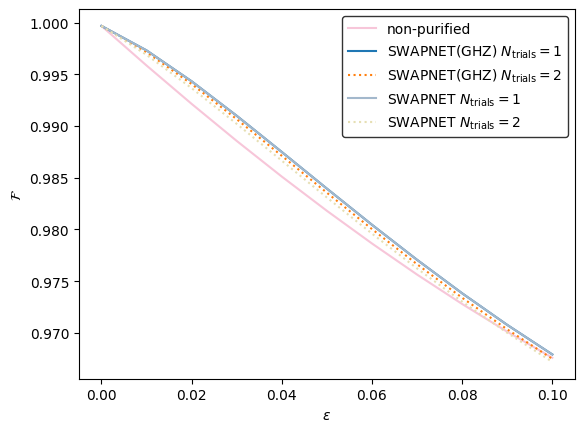

In [ ]:
plt.rcParams['text.usetex']=False
# plt.rcParams['font.serif']='Computer Modern'
# plt.rcParams['text.latex.preamble']=r'\usepackage{amsmath}'
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_unpurified_fidelity],label='non-purified', color='#F7C6D9')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n1_noisy_GHZ],label='SWAPNET(GHZ) $N_\mathrm{trials}=1$')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n2_noisy_GHZ],label='SWAPNET(GHZ) $N_\mathrm{trials}=2$', linestyle='dotted')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n1_noisy],label='SWAPNET $N_\mathrm{trials}=1$', color = '#A3B8CC')
plt.plot(list_of_epsilon,[fid**(1/24) for fid in list_of_purified_fidelity_n2_noisy],label='SWAPNET $N_\mathrm{trials}=2$', color = '#E6DFB3', linestyle='dotted')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')


plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend(loc='upper right',edgecolor = 'black')